In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
import numpy as np
import pandas as pd
import time
import scipy.stats as spst
import scipy.special as spsp
from fetch_deribit_data import *
from callibration_32model import *

import sys
sys.path.insert(sys.path.index("")+1, "C:/Users/27261/Desktop/3_Courses in PHBS/3_09_AppliedStochasticProcess/Project_sv32_EMC")
import pyfeng as pf
import pyfeng.ex as pfex
from utils import *

In [66]:
if __name__ == "__main__":
    # 放宽窗口时间，收集充足的散点
    periods = {
        "1_Pre_Shock":  ("2025-10-10 20:00:00", "2025-10-10 21:00:00"),
        "2_Crash":      ("2025-10-10 21:15:00", "2025-10-10 21:20:00"),
        "3_Recovery":   ("2025-10-10 23:00:00", "2025-10-11 00:00:00")
    }
    
    for phase_name, (start_t, end_t) in periods.items():
        print(f"\n====== 正在处理阶段: {phase_name} ({start_t} 到 {end_t}) ======")
        raw_df = fetch_deribit_trades_fast(start_t, end_t)
        
        if not raw_df.empty:
            # 1. 保存未过滤的原始数据 (Raw Data)
            raw_csv_filename = f"Deribit_RAW_{phase_name}.csv"
            raw_df.to_csv(raw_csv_filename, index=False)
            print(f"[成功] 阶段 {phase_name} 的原始成交记录 ({len(raw_df)} 条) 已保存至 {raw_csv_filename}")
            
            # 2. 清洗并保存过滤后的 OTM 数据
            print(f"[处理] 正在对 {phase_name} 进行动态 Moneyness 清洗...")
            clean_otm_df = process_and_filter_otm_dynamic(raw_df)
            
            otm_csv_filename = f"Deribit_OTM_Moneyness_{phase_name}.csv"
            clean_otm_df.to_csv(otm_csv_filename, index=False)
            print(f"[成功] 得到可用 OTM 样本 {len(clean_otm_df)} 个，已保存至 {otm_csv_filename}！")
        else:
            print(f"[警告] 阶段 {phase_name} 未拉取到数据！")


====== 正在处理阶段: 1_Pre_Shock (2025-10-10 20:00:00 到 2025-10-10 21:00:00) ======
  [引擎启动] 划分为 12 个并发块，安全全速抓取...
  [并发进度] 已完成 12/12 块 (累计获取 3437 条成交记录)...
  ✅ 所有任务结束，正在重组与去重...
[成功] 阶段 1_Pre_Shock 的原始成交记录 (1445 条) 已保存至 Deribit_RAW_1_Pre_Shock.csv
[处理] 正在对 1_Pre_Shock 进行动态 Moneyness 清洗...
[成功] 得到可用 OTM 样本 9 个，已保存至 Deribit_OTM_Moneyness_1_Pre_Shock.csv！

====== 正在处理阶段: 2_Crash (2025-10-10 21:15:00 到 2025-10-10 21:20:00) ======
  [引擎启动] 划分为 1 个并发块，安全全速抓取...
  [并发进度] 已完成 1/1 块 (累计获取 947 条成交记录)...
  ✅ 所有任务结束，正在重组与去重...
[成功] 阶段 2_Crash 的原始成交记录 (774 条) 已保存至 Deribit_RAW_2_Crash.csv
[处理] 正在对 2_Crash 进行动态 Moneyness 清洗...
[成功] 得到可用 OTM 样本 13 个，已保存至 Deribit_OTM_Moneyness_2_Crash.csv！

====== 正在处理阶段: 3_Recovery (2025-10-10 23:00:00 到 2025-10-11 00:00:00) ======
  [引擎启动] 划分为 12 个并发块，安全全速抓取...
  [并发进度] 已完成 12/12 块 (累计获取 3806 条成交记录)...
  ✅ 所有任务结束，正在重组与去重...
[成功] 阶段 3_Recovery 的原始成交记录 (1727 条) 已保存至 Deribit_RAW_3_Recovery.csv
[处理] 正在对 3_Recovery 进行动态 Moneyness 清洗...
[成功] 得到可用 OTM 样本 12 个，已保存至 Deribit_OTM_M

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set a clean plot style
plt.style.use('ggplot')

def analyze_and_plot_english(phase_name, csv_filename):
    """
    Reads CSV, calculates Call/Put Buy/Sell ratios, and plots English pie charts.
    """
    print(f"\n>>> Processing Phase: {phase_name} ({csv_filename})")
    
    if not os.path.exists(csv_filename):
        print(f"[Error] File {csv_filename} not found.")
        return

    df = pd.read_csv(csv_filename)
    if df.empty:
        print(f"[Warning] {csv_filename} is empty.")
        return

    # 1. Feature Extraction
    # Identify Call/Put from instrument name
    df['option_type'] = df['instrument_name'].apply(
        lambda x: 'Call' if x.endswith('-C') else ('Put' if x.endswith('-P') else 'Other')
    )
    
    # Format Direction
    df['trade_side'] = df['direction'].str.capitalize()
    
    # Create Category Label
    df['category'] = df['option_type'] + " " + df['trade_side']
    
    # 2. Statistical Aggregation (By Trade Amount/Volume)
    # Using 'amount' is more representative of market impact than 'count'
    stats = df.groupby('category')['amount'].sum()

    # Ensure all four quadrants exist even if 0
    required_labels = ['Call Buy', 'Call Sell', 'Put Buy', 'Put Sell']
    stats = stats.reindex(required_labels).fillna(0)

    # 3. Plotting Configuration
    labels = stats.index
    sizes = stats.values
    
    if sizes.sum() == 0:
        print(f"[Skip] Total volume is zero for {phase_name}.")
        return

    # Professional Color Palette:
    # Calls: Blues | Puts: Oranges/Reds
    colors = ['#3498db', '#2980b9', '#e67e22', '#d35400']
    explode = (0.05, 0, 0.05, 0) # Slightly separate Buys from Sells

    fig, ax = plt.subplots(figsize=(10, 7))
    
    wedges, texts, autotexts = ax.pie(
        sizes, 
        explode=explode, 
        labels=labels, 
        autopct='%1.1f%%',
        shadow=False, 
        startangle=140, 
        colors=colors,
        pctdistance=0.85,
        textprops={'fontsize': 12, 'weight': 'bold'}
    )

    # Styling the percentage text
    plt.setp(autotexts, size=10, color="white")

    # Add a center circle to make it a Donut Chart (optional, cleaner look)
    # centre_circle = plt.Circle((0,0), 0.70, fc='white')
    # fig.gca().add_artist(centre_circle)

    # 4. English Titles and Legends
    plt.title(f"Option Trade Composition: {phase_name.replace('_', ' ')}", fontsize=16, pad=20)
    ax.legend(
        wedges, 
        labels,
        title="Trade Categories",
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1),
        fontsize=11
    )

    # Save Output
    output_name = f"Chart_{phase_name}.png"
    plt.tight_layout()
    plt.savefig(output_name, dpi=300)
    print(f"[Success] Saved chart as {output_name}")
    plt.close(fig)

if __name__ == "__main__":
    # Mapping your generated CSV files
    phases = {
        "1_Pre_Shock": "Deribit_RAW_1_Pre_Shock.csv",
        "2_Crash":     "Deribit_RAW_2_Crash.csv",
        "3_Recovery":  "Deribit_RAW_3_Recovery.csv"
    }
    
    for name, file in phases.items():
        analyze_and_plot_english(name, file)


>>> Processing Phase: 1_Pre_Shock (Deribit_RAW_1_Pre_Shock.csv)
[Success] Saved chart as Chart_1_Pre_Shock.png

>>> Processing Phase: 2_Crash (Deribit_RAW_2_Crash.csv)
[Success] Saved chart as Chart_2_Crash.png

>>> Processing Phase: 3_Recovery (Deribit_RAW_3_Recovery.csv)
[Success] Saved chart as Chart_3_Recovery.png


In [33]:
# 运行代码
if __name__ == "__main__":
    # 假设闪崩发生在 2024年10月11日，我们取这之前 180 天的数据
    # 你可以修改为你实际研究的日期
    k_est, t_est = fetch_dvol_and_estimate_32_parameters(end_date_str='2025-10-10', days_lookback=180)

📥 正在从 Deribit 抓取闪崩前 180 天的 BTC DVOL 数据...
✅ 3/2 模型专属离散化回归完成！(样本数: 180 天)
---------------------------------------------
统计区间: 2025-04-12 至 2025-10-09
回归方程: dV/V = (0.0530) + (-0.3307) * V_prev
---------------------------------------------
🎯 估计的长期方差 (Theta):    0.160194 (约 40.0% IV)
🎯 估计的均值回归速度 (Kappa): 120.7079
---------------------------------------------
[附] 回归 R^2: 0.0552, p-value(斜率): 1.50e-03


In [67]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

RAW_FILES = {
    "1_Pre_Shock": "Deribit_RAW_1_Pre_Shock.csv",
    "2_Crash":     "Deribit_RAW_2_Crash.csv",
    "3_Recovery":  "Deribit_RAW_3_Recovery.csv"
}

# 🎯 已经换成真实的流动性绿洲坐标
TARGET_MATURITIES = {
    "20D": 20.3 / 365.25,
    "48D": 48.3 / 365.25,
    # "76D": 76.0 / 365.25
}

def clean_and_split_smart():
    for stage_name, raw_file in RAW_FILES.items():
        print(f"\n📂 正在读取并智能提纯: {raw_file}")
        
        if not os.path.exists(raw_file):
            print(f"  ❌ 文件不存在，跳过。")
            continue
            
        df = pd.read_csv(raw_file)
        
        # 1. 拆解参数
        parts = df['instrument_name'].str.split('-', expand=True)
        df['Expiry_Str'] = parts[1]
        df['K'] = parts[2].astype(float)
        df['Type'] = parts[3]
        
        # 2. 时间处理
        df['Trade_Time'] = pd.to_datetime(df['datetime'], format='mixed')
        df['Expiry_Time'] = pd.to_datetime(df['Expiry_Str'], format='%d%b%y') + pd.Timedelta(hours=8)
        df['T'] = (df['Expiry_Time'] - df['Trade_Time']).dt.total_seconds() / (365.25 * 24 * 3600)
        
        # 3. 聚合去重 (💥 注意这里加入了 Expiry_Str 作为保留字段)
        df_agg = df.groupby(['instrument_name', 'Expiry_Str']).agg({
            'index_price': 'mean',
            'iv': 'mean',
            'K': 'first',
            'Type': 'first',
            'T': 'mean'
        }).reset_index()
        
        # 4. 提取 OTM 虚值期权
        df_agg['Moneyness'] = df_agg['K'] / df_agg['index_price']
        cond_call = (df_agg['Type'] == 'C') & (df_agg['Moneyness'] >= 1.0)
        cond_put = (df_agg['Type'] == 'P') & (df_agg['Moneyness'] <= 1.0)
        df_otm = df_agg[cond_call | cond_put].copy()
        
        if df_otm.empty:
            print(f"  ⚠️ 没有有效的虚值期权！")
            continue

        # 💥 核心修复：计算每个【交割日】的平均 T，而不是把微小差异的 T 当作独立的期限
        expiry_T_mapping = df_otm.groupby('Expiry_Str')['T'].mean()
        
        for maturity_label, target_T in TARGET_MATURITIES.items():
            best_expiry = None
            min_diff = float('inf')
            
            # 遍历每一个交割日 (比如 '31OCT25')
            for exp_str, t_mean in expiry_T_mapping.items():
                
                # 统一放宽截断区间，保留核心交战区 (M 在 0.5 到 2.0 之间)
                subset = df_otm[(df_otm['Expiry_Str'] == exp_str) & 
                                (df_otm['Moneyness'] >= 0.5) & 
                                (df_otm['Moneyness'] <= 2.0)]
                
                # 只有样本数 >= 3，我们才认为它能构成一条微笑曲线
                if len(subset) >= 3:
                    diff = np.abs(t_mean - target_T)
                    if diff < min_diff:
                        min_diff = diff
                        best_expiry = exp_str
            
            if best_expiry is None:
                print(f"  ⚠️ [{maturity_label}] 失败！没有任何一个期限包含 >= 3 个虚值期权。")
                pd.DataFrame(columns=['Moneyness', 'Type', 'iv', 'T']).to_csv(f"Deribit_{maturity_label}_{stage_name}.csv", index=False)
                continue
                
            # 提取最终的最佳数据集
            df_slice = df_otm[(df_otm['Expiry_Str'] == best_expiry) & 
                              (df_otm['Moneyness'] >= 0.5) & 
                              (df_otm['Moneyness'] <= 2.0)].copy()
                
            df_final = df_slice[['Moneyness', 'Type', 'iv', 'T']].copy()
            df_final = df_final.sort_values('Moneyness').reset_index(drop=True)
            
            output_filename = f"Deribit_{maturity_label}_{stage_name}.csv"
            df_final.to_csv(output_filename, index=False)
            
            actual_days = expiry_T_mapping[best_expiry] * 365.25
            print(f"  ✅ [{maturity_label}] 导出至: {output_filename}")
            print(f"     -> 锚定交割日: {best_expiry} | 匹配天数: {actual_days:.2f}天 | 有效样本数: {len(df_final)}")

if __name__ == "__main__":
    clean_and_split_smart()


📂 正在读取并智能提纯: Deribit_RAW_1_Pre_Shock.csv
  ✅ [20D] 导出至: Deribit_20D_1_Pre_Shock.csv
     -> 锚定交割日: 31OCT25 | 匹配天数: 20.47天 | 有效样本数: 33
  ✅ [48D] 导出至: Deribit_48D_1_Pre_Shock.csv
     -> 锚定交割日: 28NOV25 | 匹配天数: 48.47天 | 有效样本数: 27

📂 正在读取并智能提纯: Deribit_RAW_2_Crash.csv
  ✅ [20D] 导出至: Deribit_20D_2_Crash.csv
     -> 锚定交割日: 31OCT25 | 匹配天数: 20.45天 | 有效样本数: 33
  ✅ [48D] 导出至: Deribit_48D_2_Crash.csv
     -> 锚定交割日: 28NOV25 | 匹配天数: 48.45天 | 有效样本数: 26

📂 正在读取并智能提纯: Deribit_RAW_3_Recovery.csv
  ✅ [20D] 导出至: Deribit_20D_3_Recovery.csv
     -> 锚定交割日: 31OCT25 | 匹配天数: 20.36天 | 有效样本数: 34
  ✅ [48D] 导出至: Deribit_48D_3_Recovery.csv
     -> 锚定交割日: 28NOV25 | 匹配天数: 48.35天 | 有效样本数: 23


正在透视底层数据: Deribit_RAW_3_Recovery.csv

🔥 发现真正的流动性绿洲 (按有效虚值成交笔数排名):
   -> 距离到期  20.3 天 | 虚值成交量: 999 笔
   -> 距离到期  48.3 天 | 虚值成交量: 295 笔
   -> 距离到期  76.0 天 | 虚值成交量: 289 笔
   -> 距离到期  20.0 天 | 虚值成交量: 279 笔
   -> 距离到期  76.3 天 | 虚值成交量: 270 笔


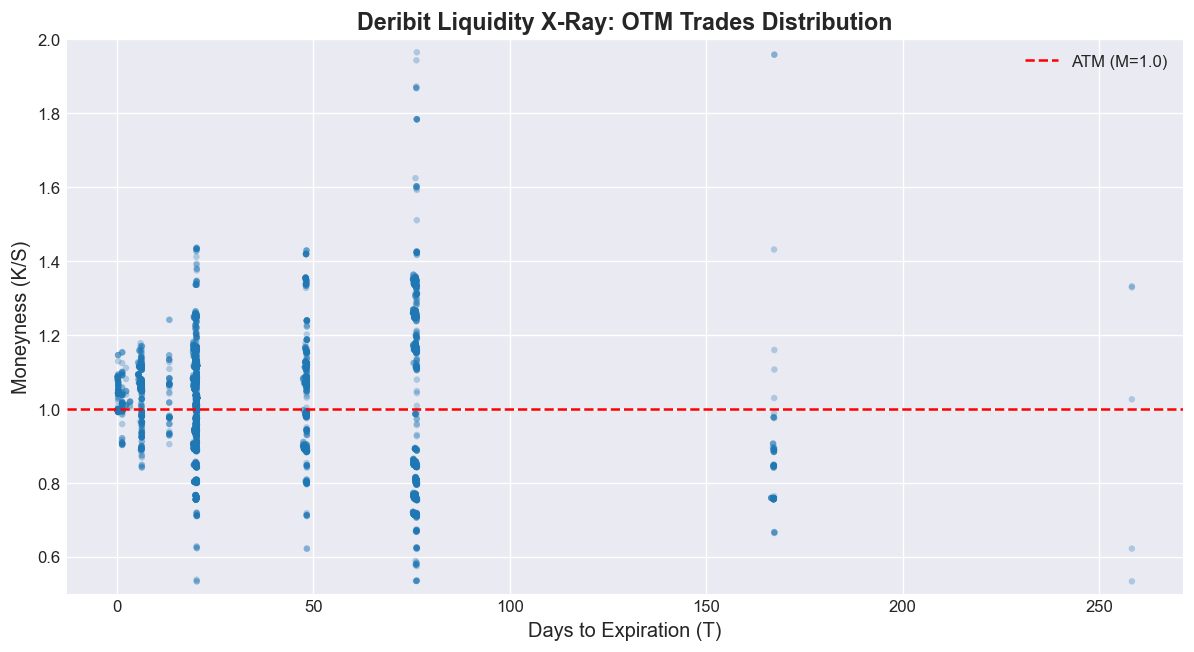

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

def liquidity_xray(raw_csv):
    print(f"正在透视底层数据: {raw_csv}")
    df = pd.read_csv(raw_csv)
    
    # 拆解参数
    parts = df['instrument_name'].str.split('-', expand=True)
    df['Expiry_Str'] = parts[1]
    df['K'] = parts[2].astype(float)
    df['Type'] = parts[3]
    
    # 计算时间
    df['Trade_Time'] = pd.to_datetime(df['datetime'], format='mixed')
    df['Expiry_Time'] = pd.to_datetime(df['Expiry_Str'], format='%d%b%y') + pd.Timedelta(hours=8)
    
    # 计算精确的“距离到期天数 (Days to Expiry)”
    df['T_days'] = (df['Expiry_Time'] - df['Trade_Time']).dt.total_seconds() / (24 * 3600)
    df['Moneyness'] = df['K'] / df['index_price']
    
    # 提取虚值期权 (OTM)
    cond_call = (df['Type'] == 'C') & (df['Moneyness'] >= 1.0)
    cond_put = (df['Type'] == 'P') & (df['Moneyness'] <= 1.0)
    df_otm = df[cond_call | cond_put].copy()
    
    # ==========================================
    # 打印流动性最集中的真实期限
    # ==========================================
    print("\n🔥 发现真正的流动性绿洲 (按有效虚值成交笔数排名):")
    # 将天数四舍五入到小数点后 1 位，方便归类
    top_expiries = df_otm['T_days'].round(1).value_counts().head(5)
    for t_days, count in top_expiries.items():
        print(f"   -> 距离到期 {t_days:>5.1f} 天 | 虚值成交量: {count} 笔")

    # ==========================================
    # 绘制 X-Ray 透视图
    # ==========================================
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(12, 6), dpi=120)
    
    # 画出所有的 OTM 散点
    plt.scatter(df_otm['T_days'], df_otm['Moneyness'], 
                alpha=0.3, s=15, c='#1f77b4', edgecolor='none')
    
    plt.title('Deribit Liquidity X-Ray: OTM Trades Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Days to Expiration (T)', fontsize=12)
    plt.ylabel('Moneyness (K/S)', fontsize=12)
    plt.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='ATM (M=1.0)')
    
    # 限制 Y 轴只看核心区，防止极端脏数据拉坏比例
    plt.ylim(0.5, 2.0)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    # 替换为你抓到的包含 24 小时的完整 RAW 文件
    liquidity_xray("Deribit_RAW_3_Recovery.csv")


正在处理 1. Pre-Shock...
  -> ATM IV: 40.0%, VoV: 3.04, Rho: -0.99, Jump Vol: 0.16

正在处理 2. Crash...
  -> ATM IV: 48.7%, VoV: 4.40, Rho: -0.99, Jump Vol: 0.53

正在处理 3. Recovery...
  -> ATM IV: 40.8%, VoV: 2.11, Rho: -0.88, Jump Vol: 0.16


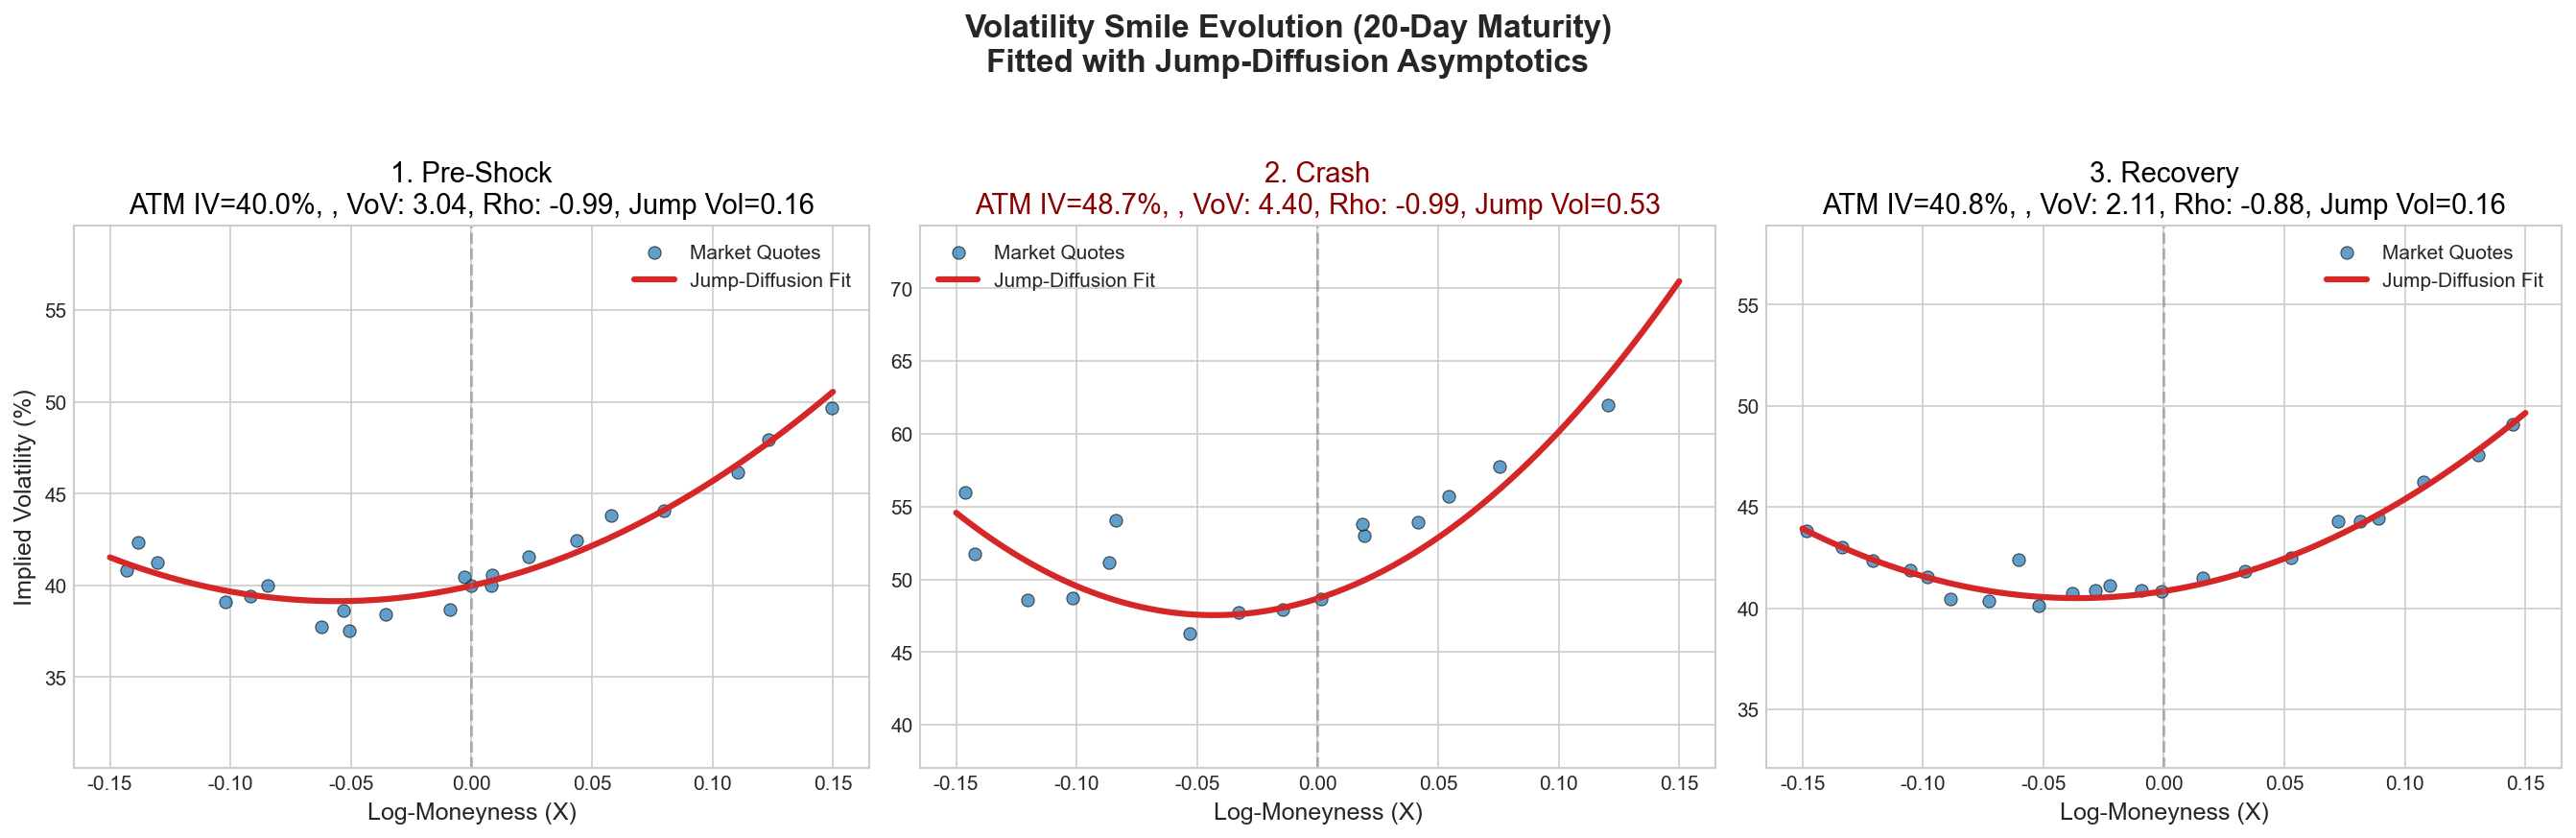


✅ 绘图完成！图片已保存为 Flash_Crash_20D_Evolution.png


In [70]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. 核心数学公式: Medvedev & Scaillet (2007) 含跳跃项
# ==========================================
def medvedev_scaillet_jump_iv(X_array, atm_iv, vov, rho, jump_vol, T):
    coef_X = (vov * rho / 4.0) * atm_iv
    diff_curv = (vov**2 * atm_iv / 48.0) * (2.0 - rho**2)
    jump_curv = (np.sqrt(2 * np.pi) / 4.0) * (jump_vol / (atm_iv**2 * np.sqrt(T)))
    coef_X2 = diff_curv + jump_curv
    return atm_iv - coef_X * X_array + coef_X2 * (X_array**2)

def objective_ms_jump(params, X_array, market_ivs, atm_iv, T):
    vov, rho, jump_vol = params
    # 物理边界保护
    if vov <= 0.01 or vov > 20.0 or rho < -0.999 or rho > 0.999 or jump_vol < 0.0:
        return 1e10
    model_ivs = medvedev_scaillet_jump_iv(X_array, atm_iv, vov, rho, jump_vol, T)
    return np.mean((model_ivs - market_ivs)**2)

# ==========================================
# 2. 单文件校准引擎
# ==========================================
def calibrate_single_dataset(csv_filepath):
    try:
        df = pd.read_csv(csv_filepath)
    except Exception:
        return None, None, f"❌ 读取失败: {csv_filepath}"

    T = df['T'].iloc[0]
    r = 0.0
    df['X'] = -np.log(df['Moneyness']) + r * T
    
    # 提取 ATM IV
    atm_idx = np.abs(df['X']).argmin()
    atm_iv = df['iv'].iloc[atm_idx] / 100.0 if df['iv'].mean() > 5 else df['iv'].iloc[atm_idx]
    
    # 放宽 X 轴提取区间，让 OTM 散点尽可能多参与拟合 (-0.15 到 0.15 约等于 M 0.85 到 1.15)
    df_filtered = df[(df['X'] >= -0.15) & (df['X'] <= 0.15)].copy()
    if len(df_filtered) < 3:
        return None, None, "❌ 过滤后有效虚值样本不足 3 个"
        
    X_array = df_filtered['X'].values
    market_ivs = df_filtered['iv'].values / 100.0 if df_filtered['iv'].mean() > 5 else df_filtered['iv'].values
    
    # 寻优初始值与边界 (放开 jump_vol 上限捕捉极值)
    initial_guess = [2.0, -0.5, 0.5]
    bounds = [(0.1, 15.0), (-0.99, 0.99), (0.001, 30.0)]
    
    res = minimize(
        objective_ms_jump, initial_guess, 
        args=(X_array, market_ivs, atm_iv, T), 
        method='L-BFGS-B', bounds=bounds
    )
    
    if res.success:
        vov, rho, jump_vol = res.x
        return df_filtered, {"atm_iv": atm_iv, "vov": vov, "rho": rho, "jump_vol": jump_vol, "T": T}, "✅ 成功"
    else:
        return None, None, "❌ 优化失败"

# ==========================================
# 3. 专注版 1x3 绘图主函数
# ==========================================
def run_20d_analysis():
    # 填入你清洗出的 20D 文件名
    files = {
        "1. Pre-Shock": "Deribit_20D_1_Pre_Shock.csv",
        "2. Crash":     "Deribit_20D_2_Crash.csv",
        "3. Recovery":  "Deribit_20D_3_Recovery.csv"
    }
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=150)
    fig.suptitle('Volatility Smile Evolution (20-Day Maturity)\nFitted with Jump-Diffusion Asymptotics', 
                 fontsize=16, fontweight='bold', y=1.05)
    
    for idx, (stage, filepath) in enumerate(files.items()):
        ax = axes[idx]
        print(f"\n正在处理 {stage}...")
        
        df_plot, params, status = calibrate_single_dataset(filepath)
        
        if not params:
            ax.text(0.5, 0.5, f"Data Error:\n{status}", ha='center', va='center', fontsize=12, color='red')
            ax.set_title(f"{stage}")
            continue
            
        # 打印控制台报告
        print(f"  -> ATM IV: {params['atm_iv']*100:.1f}%, VoV: {params['vov']:.2f}, Rho: {params['rho']:.2f}, Jump Vol: {params['jump_vol']:.2f}")
        
        market_X = df_plot['X'].values
        market_ivs = df_plot['iv'].values / 100.0 if df_plot['iv'].mean() > 5 else df_plot['iv'].values
        
        # 绘制拟合平滑曲线
        smooth_X = np.linspace(-0.15, 0.15, 300)
        model_ivs = medvedev_scaillet_jump_iv(
            smooth_X, params["atm_iv"], params["vov"], params["rho"], params["jump_vol"], params["T"]
        )
        
        # 散点与折线
        ax.scatter(market_X, market_ivs * 100, color='#1f77b4', alpha=0.7, edgecolor='black', s=40, label='Market Quotes')
        ax.plot(smooth_X, model_ivs * 100, color='#d62728', linewidth=3, label='Jump-Diffusion Fit')
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        
        # 统一 Y 轴，凸显 Crash 时的高度
        ax.set_ylim([min(market_ivs*100)*0.8, max(market_ivs*100)*1.2])
        
        title_color = 'darkred' if 'Crash' in stage else 'black'
        ax.set_title(f"{stage}\nATM IV={params['atm_iv']*100:.1f}%, , VoV: {params['vov']:.2f}, Rho: {params['rho']:.2f}, Jump Vol={params['jump_vol']:.2f}", 
                     fontsize=14, color=title_color)
        
        ax.set_xlabel('Log-Moneyness (X)', fontsize=12)
        if idx == 0:
            ax.set_ylabel('Implied Volatility (%)', fontsize=12)
            
        ax.legend(loc='best', fontsize=10)

    plt.tight_layout()
    plt.savefig('Flash_Crash_20D_Evolution.png', bbox_inches='tight')
    plt.show()
    print("\n✅ 绘图完成！图片已保存为 Flash_Crash_20D_Evolution.png")

if __name__ == "__main__":
    run_20d_analysis()


正在处理 1. Pre-Shock (纯扩散组)...
  -> ATM IV: 40.0%, VoV: 12.88, Rho: -0.23

正在处理 2. Crash (纯扩散组)...
  -> ATM IV: 48.7%, VoV: 17.69, Rho: -0.25

正在处理 3. Recovery (纯扩散组)...
  -> ATM IV: 40.8%, VoV: 12.53, Rho: -0.15


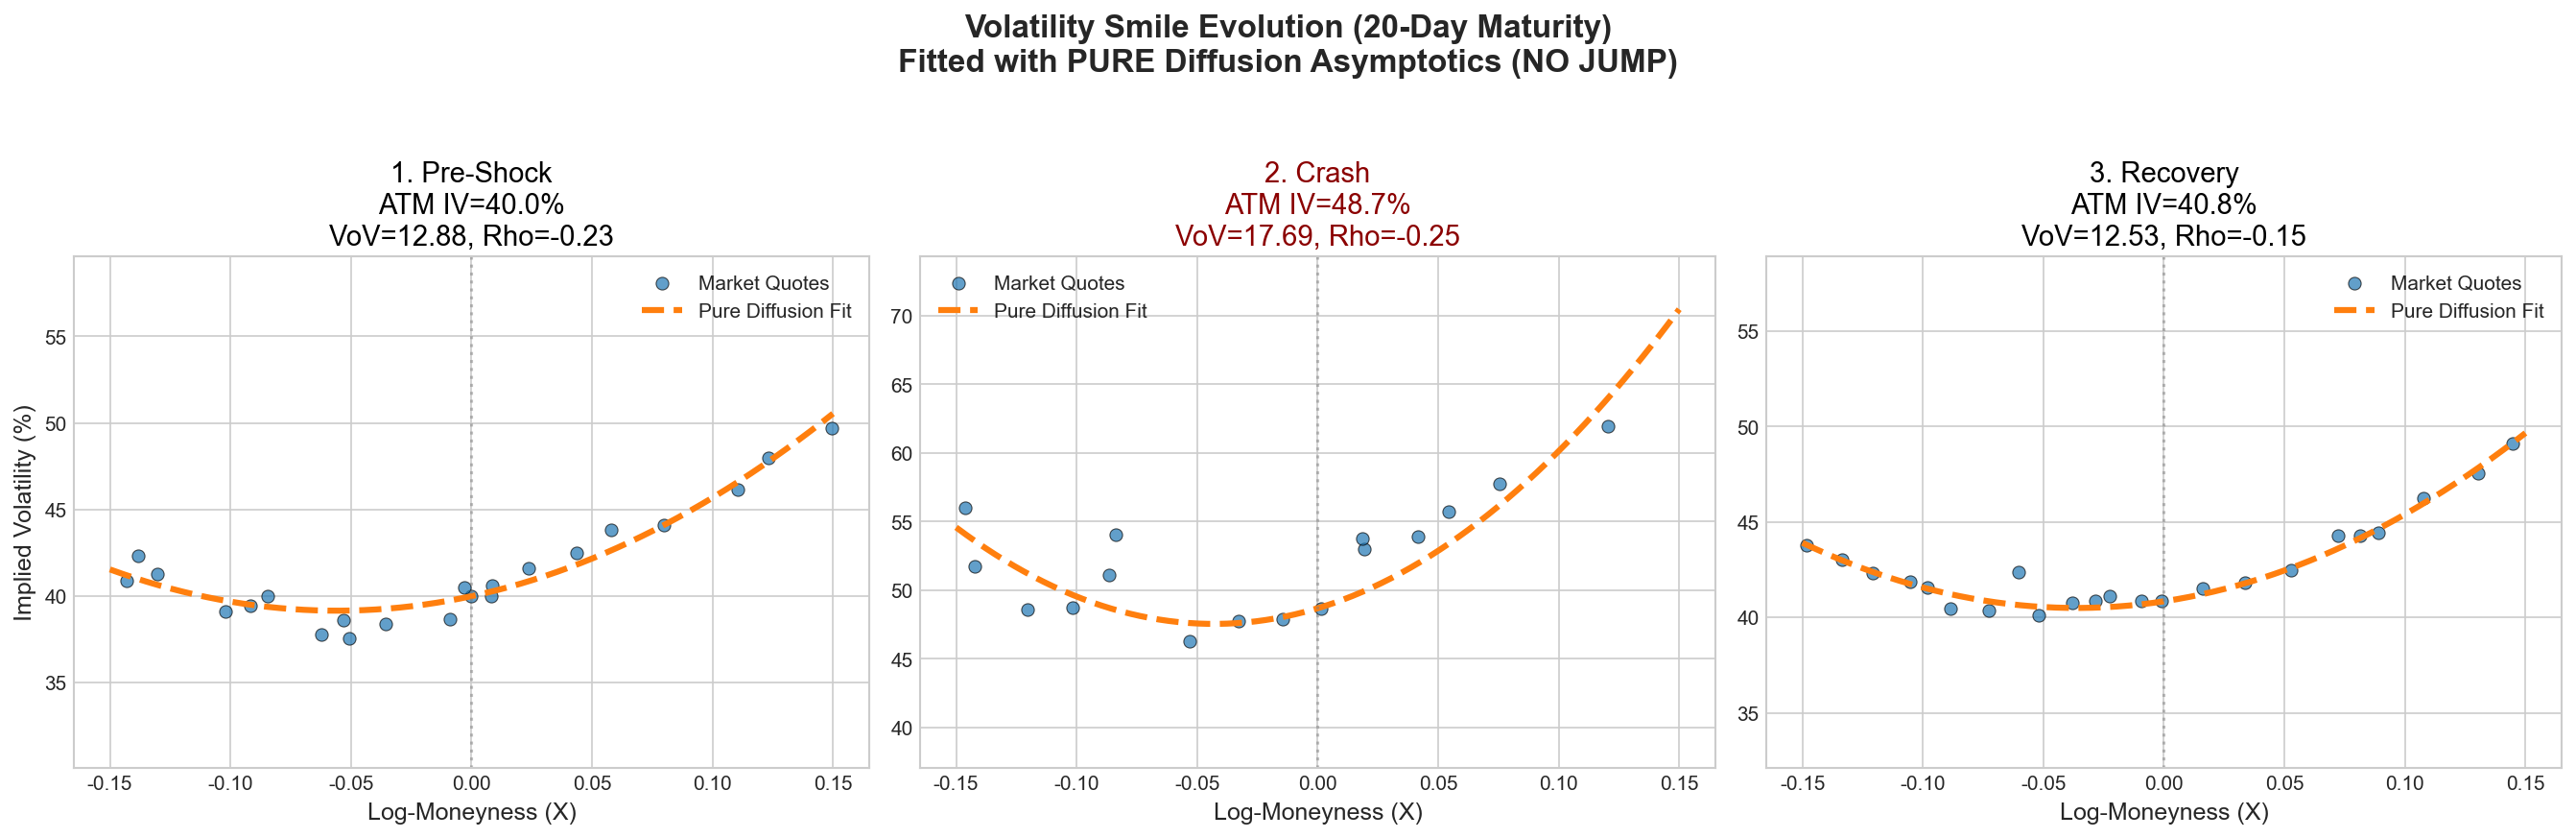


✅ 对照组绘图完成！图片已保存为 Flash_Crash_20D_Evolution_NoJump.png


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. 核心数学公式: 纯扩散 3/2 模型 (无跳跃项)
# ==========================================
def medvedev_scaillet_no_jump_iv(X_array, atm_iv, vov, rho):
    """
    剥离跳跃后的纯扩散曲率。
    在 T 极小时，它能提供的曲率上限被死死限制住了。
    """
    # 扩散倾斜项
    coef_X = (vov * rho / 4.0) * atm_iv
    # 扩散曲率项
    diff_curv = (vov**2 * atm_iv / 48.0) * (2.0 - rho**2)
    
    # 纯扩散的总曲率
    coef_X2 = diff_curv
    
    return atm_iv - coef_X * X_array + coef_X2 * (X_array**2)

def objective_ms_no_jump(params, X_array, market_ivs, atm_iv):
    vov, rho = params
    # 物理边界保护
    if vov <= 0.01 or vov > 20.0 or rho < -0.999 or rho > 0.999:
        return 1e10
    model_ivs = medvedev_scaillet_no_jump_iv(X_array, atm_iv, vov, rho)
    return np.mean((model_ivs - market_ivs)**2)

# ==========================================
# 2. 单文件校准引擎 (无跳跃版)
# ==========================================
def calibrate_single_dataset_no_jump(csv_filepath):
    try:
        df = pd.read_csv(csv_filepath)
    except Exception:
        return None, None, f"❌ 读取失败: {csv_filepath}"

    T = df['T'].iloc[0]
    r = 0.0
    df['X'] = -np.log(df['Moneyness']) + r * T
    
    # 提取 ATM IV
    atm_idx = np.abs(df['X']).argmin()
    atm_iv = df['iv'].iloc[atm_idx] / 100.0 if df['iv'].mean() > 5 else df['iv'].iloc[atm_idx]
    
    # 截取核心交战区
    df_filtered = df[(df['X'] >= -0.15) & (df['X'] <= 0.15)].copy()
    if len(df_filtered) < 3:
        return None, None, "❌ 过滤后样本不足"
        
    X_array = df_filtered['X'].values
    market_ivs = df_filtered['iv'].values / 100.0 if df_filtered['iv'].mean() > 5 else df_filtered['iv'].values
    
    # 仅需拟合 2 个参数: VoV 和 Rho
    initial_guess = [2.0, -0.5]
    bounds = [(0.1, 20.0), (-0.99, 0.99)]
    
    res = minimize(
        objective_ms_no_jump, initial_guess, 
        args=(X_array, market_ivs, atm_iv), 
        method='L-BFGS-B', bounds=bounds
    )
    
    if res.success:
        vov, rho = res.x
        return df_filtered, {"atm_iv": atm_iv, "vov": vov, "rho": rho}, "✅ 成功"
    else:
        return None, None, "❌ 优化失败"

# ==========================================
# 3. 对照组 1x3 绘图主函数
# ==========================================
def run_20d_no_jump_analysis():
    files = {
        "1. Pre-Shock": "Deribit_20D_1_Pre_Shock.csv",
        "2. Crash":     "Deribit_20D_2_Crash.csv",
        "3. Recovery":  "Deribit_20D_3_Recovery.csv"
    }
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=150)
    fig.suptitle('Volatility Smile Evolution (20-Day Maturity)\nFitted with PURE Diffusion Asymptotics (NO JUMP)', 
                 fontsize=16, fontweight='bold', y=1.05)
    
    for idx, (stage, filepath) in enumerate(files.items()):
        ax = axes[idx]
        print(f"\n正在处理 {stage} (纯扩散组)...")
        
        df_plot, params, status = calibrate_single_dataset_no_jump(filepath)
        
        if not params:
            ax.text(0.5, 0.5, f"Data Error:\n{status}", ha='center', va='center', fontsize=12, color='red')
            ax.set_title(f"{stage}")
            continue
            
        print(f"  -> ATM IV: {params['atm_iv']*100:.1f}%, VoV: {params['vov']:.2f}, Rho: {params['rho']:.2f}")
        
        market_X = df_plot['X'].values
        market_ivs = df_plot['iv'].values / 100.0 if df_plot['iv'].mean() > 5 else df_plot['iv'].values
        
        smooth_X = np.linspace(-0.15, 0.15, 300)
        model_ivs = medvedev_scaillet_no_jump_iv(
            smooth_X, params["atm_iv"], params["vov"], params["rho"]
        )
        
        ax.scatter(market_X, market_ivs * 100, color='#1f77b4', alpha=0.7, edgecolor='black', s=40, label='Market Quotes')
        ax.plot(smooth_X, model_ivs * 100, color='#ff7f0e', linewidth=3, linestyle='--', label='Pure Diffusion Fit')
        ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
        
        ax.set_ylim([min(market_ivs*100)*0.8, max(market_ivs*100)*1.2])
        
        title_color = 'darkred' if 'Crash' in stage else 'black'
        ax.set_title(f"{stage}\nATM IV={params['atm_iv']*100:.1f}%\nVoV={params['vov']:.2f}, Rho={params['rho']:.2f}", 
                     fontsize=14, color=title_color)
        
        ax.set_xlabel('Log-Moneyness (X)', fontsize=12)
        if idx == 0:
            ax.set_ylabel('Implied Volatility (%)', fontsize=12)
            
        ax.legend(loc='best', fontsize=10)

    plt.tight_layout()
    plt.savefig('Flash_Crash_20D_Evolution_NoJump.png', bbox_inches='tight')
    plt.show()
    print("\n✅ 对照组绘图完成！图片已保存为 Flash_Crash_20D_Evolution_NoJump.png")

if __name__ == "__main__":
    run_20d_no_jump_analysis()